<h1 align="center"><font color="gree">🦷 Tooth segmentation with YOLO 🦷</font></h1>

<font color="pink">Senior Data Scientist/AI Engineering.: Dr. Eddy Giusepe Chirinos Isidro</font>

## <font color="blue">Contexto e Motivação</font>

A radiografia panorâmica dental é um dos exames de imagem mais requisitados na odontologia moderna. Em uma única imagem de baixa dose de radiação, ela fornece visualização simultânea de toda a arcada dentária e das estruturas maxilofaciais — sendo obrigatória em especialidades como `Ortodontia`, `Cirurgia Oral` e `Implantodontia`. Contudo, a interpretação manual dessas radiografias é `demorada, cognitivamente exigente e sujeita à variabilidade entre observadores`, especialmente em ambientes clínicos de alto volume, onde achados incidentais podem passar despercebidos.

A automação inteligente desse processo representa um avanço significativo para a odontologia digital, servindo como fundação para aplicações downstream como diagnóstico automatizado, planejamento de tratamento e monitoramento longitudinal de pacientes.

---

## <font color="blue">O Problema: Identificação e Numeração dos Dentes</font>

Antes de qualquer procedimento ou diagnóstico, o profissional de saúde precisa identificar com precisão **qual dente é qual**. O padrão internacional adotado é o `Sistema FDI
(Fédération Dentaire Internationale — ISO 3950)`, que define 32 posições dentárias distribuídas em quatro quadrantes, cada uma exigindo classificação espacialmente consistente.

Neste projeto, treinamos um modelo de segmentação de instâncias capaz de:
- `Detectar` cada dente individualmente na radiografia panorâmica
- `Segmentar` com precisão os contornos de cada dente
- `Numerar` automaticamente cada dente segundo o sistema FDI (32 classes)

---

## <font color="blue">Por que isso é importante?</font>

A segmentação dental precisa abre caminho para uma cadeia completa de aplicações clínicas:

| Aplicação | Descrição |
|-----------|-----------|
| `Planejamento de implantes` | Localização precisa de espaços edêntulos para posicionamento de implantes |
| `Ortodontia digital` | Análise de posicionamento e movimentação dentária ao longo do tratamento |
| `Detecção de cáries e patologias` | Associação de lesões a posições dentárias específicas via FDI |
| `CAD/CAM (coroas e próteses)` | Base geométrica para design assistido por computador de restaurações |
| `Geração de laudos automáticos` | Relatórios estruturados associando achados à numeração do dente |
| `Triagem em saúde pública` | Análise em larga escala de populações com recursos humanos limitados |

---

## <font color="blue">Abordagem Técnica</font>

Este notebook implementa uma pipeline completa de segmentação dental utilizando:

- `Modelo:` YOLOv8m-seg (variante medium, pré-treinada no COCO)
- `Dataset:` [Teeth Segmentation on Dental X-ray Images](https://www.kaggle.com/datasets/humansintheloop/teeth-segmentation-on-dental-x-ray-images) — 598 radiografias panorâmicas com anotações em formato Supervisely JSON
- `Formato de anotação:` Supervisely JSON → convertido para YOLO segmentation
- `Classes:` 32 classes FDI (UR1–LR8, nomenclatura Universal adaptada)
- `Divisão:` 80% treino / 10% validação / 10% teste
- `Rastreamento:` Weights & Biases (W&B) para monitoramento em tempo real

## <font color="blue">Resultados obtidos (50 epochs — modelo preliminar)</font>

| Métrica | Valor |
|---------|-------|
| mAP50 (Box) | **0.946** |
| mAP50 (Mask) | **0.938** |
| Precision | 0.934 |
| Recall | 0.889 |

---

## <font color="blue">Stack Tecnológica</font>

`Python` · `Ultralytics YOLOv8` · `PyTorch` · `Weights & Biases` · `KaggleHub` · `Pillow` · `Matplotlib`

# <font color="red">Nossas bibliotecas e login no W&B</font>

In [1]:
import json
import random
import shutil
import time
from pathlib import Path
import wandb
import kagglehub
import matplotlib.image as mpimg
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np
from matplotlib.patches import Polygon
from PIL import Image
from ultralytics import YOLO
import colorsys

import os
from dotenv import load_dotenv, find_dotenv
_ = load_dotenv(find_dotenv()) # read local .env file
Eddy_key_wandb  = os.environ['WANDB_API_KEY']


# 1. Login (já está na célula de imports)
wandb.login(key=Eddy_key_wandb)

# 2. Ativa no Ultralytics
from ultralytics import settings
settings.update({'wandb': True})

# 3. Inicializa o run
wandb.init(project="tooth-segmentation", # Nome do projeto no W&B
           name="teeth_safe_run" # Nome do experimento no W&B
          )

# 4. Treina normalmente
#results = model.train(...)


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /home/eddygiusepe/.netrc
wandb: Currently logged in as: eddygiusepe to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [2]:
import wandb
from ultralytics import settings

print("W&B logado:", wandb.api.api_key is not None)
print("W&B ativo no Ultralytics:", settings.get('wandb'))
print("W&B versão:", wandb.__version__)

wandb: WARNING wandb.api and wandb.ensure_configured() are deprecated and will be removed in a future release. To check for credentials without prompting, use wandb.login(prompt=False).


W&B logado: True
W&B ativo no Ultralytics: True
W&B versão: 0.30.0


# <font color="red">Baixamos nosso Dataset</font>

A função `kagglehub.dataset_download()` baixa o dataset para um cache global do sistema, localizado em `path`.
A variável `path` retornada aponta exatamente para esse diretório .

In [ ]:
start = time.time()

path = kagglehub.dataset_download("humansintheloop/teeth-segmentation-on-dental-x-ray-images")

elapsed = time.time() - start

print(f"Path to dataset files: {path}")
print(f"Download concluído em {elapsed:.2f} segundos")


# <font color="red">Estabelecemos os diretórios de trabalho</font>

Temos os seguintes diretórios:

* `DATASET_ROOT` — aponta para a pasta raiz do dataset no cache do kagglehub (o valor de path)

* `JSON_ROOT` — entra na pasta `Teeth Segmentation JSON/d2/`, onde estão os dados reais

* `d2` — é o nome do subconjunto usado neste dataset. O dataset original do Kaggle pode ter múltiplos subconjuntos (d1, d2, etc.), cada um com suas imagens e anotações. Aqui usamos o d2

* `ANN_DIR` — pasta `ann/` (de annotations): contém um arquivo `.json` por imagem com os polígonos de segmentação de cada dente

* `IMG_DIR` — pasta `img/` (de images): contém as imagens de raio-X em `.jpg`

* `WORK_DIR` — raiz do seu projeto (não do dataset), resolvida como caminho absoluto

* `YOLO_DIR` — pasta `yolo_dataset/` dentro do seu projeto, onde o dataset convertido será salvo

In [ ]:
DATASET_ROOT = Path(path)
JSON_ROOT    = DATASET_ROOT / 'Teeth Segmentation JSON' / 'd2'
ANN_DIR      = JSON_ROOT / 'ann'
IMG_DIR      = JSON_ROOT / 'img'
WORK_DIR     = Path('.').resolve()  # caminho absoluto da raiz do projeto
YOLO_DIR     = WORK_DIR / 'yolo_dataset'

print('Images      :', len(list(IMG_DIR.glob('*'))))
print('Annotations :', len(list(ANN_DIR.glob('*.json'))))


# <font color="red">Visualizamos algumas imagens escolhidas aleatoriamente</font>

In [ ]:
img_files = list(IMG_DIR.glob('*'))
sample = random.sample(img_files, 6)  # mostra 6 imagens

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, img_path in zip(axes, sample):
    img = mpimg.imread(img_path)
    ax.imshow(img, cmap='gray')
    ax.set_title(img_path.name, fontsize=8)
    ax.axis('off')

plt.suptitle('Imagens de raio-X dentais', fontsize=20, color='red')
plt.tight_layout()
plt.show()


# <font color="red">Visualizando a imagem original em Raio-X e a sua segmentação respectiva</font>

Nesta seção comparamos a radiografia panorâmica original com as segmentações produzidas pelos anotadores humanos.

* `Primeira visualização` — mostra a radiografia original em escala de cinza (à esquerda) e os polígonos de segmentação reconstruídos diretamente a partir do arquivo `.json` correspondente (à direita). Cada polígono representa um dente identificado manualmente.

* `Segunda visualização` — exibe diretamente as imagens da pasta `masks_human`, onde cada arquivo já é um par pré-renderizado contendo a radiografia original ao lado da máscara colorida. Essas imagens foram geradas pela plataforma `Supervisely` a partir das anotações dos especialistas e representam o `ground truth` do dataset — a referência mais confiável para o treinamento do modelo.

In [ ]:
# Escolhe uma imagem aleatória:
img_files = list(IMG_DIR.glob('*'))
img_path = random.choice(img_files)

# Carrega o JSON correspondente:
ann_path = ANN_DIR / (img_path.name + '.json')

img = mpimg.imread(img_path)

with open(ann_path) as f:
    ann = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Imagem original:
axes[0].imshow(img, cmap='gray')
axes[0].set_title(f'Original: {img_path.name}', fontsize=18, color='red')
axes[0].axis('off')

# Imagem com segmentações:
axes[1].imshow(img, cmap='gray')
for obj in ann['objects']:
    if obj['geometryType'] == 'polygon':
        pts = np.array(obj['labelerLogin'] if False else
                       [[p[0], p[1]] for p in obj['points']['exterior']])
        poly = Polygon(pts, closed=True, alpha=0.4)
        axes[1].add_patch(poly)
axes[1].set_title(f'Com Segmentação: {img_path.name}', fontsize=18, color='blue')
axes[1].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
MASK_DIR = JSON_ROOT / 'masks_human'

# Pega algumas máscaras aleatórias para exibir
mask_files = list(MASK_DIR.glob('*.png'))
sample = random.sample(mask_files, 3)

fig, axes = plt.subplots(3, 1, figsize=(18, 12))

for ax, mask_path in zip(axes, sample):
    mask = mpimg.imread(mask_path)
    ax.imshow(mask)
    ax.set_title(mask_path.name, fontsize=12)
    ax.axis('off')

plt.suptitle('Amostras: Original + Segmentação Humana', fontsize=18, color='red')
plt.tight_layout()
plt.show()


# <font color="red">Definição das 32 classes</font>

O sistema `FDI` (Fédération Dentaire Internationale — Federação Dentária Internacional) é a convenção médica universal para numeração de dentes, adotada pela Organização Mundial da Saúde (OMS) e utilizada por dentistas em todo o mundo. Nele, cada dente recebe um código único baseado no quadrante da boca e sua posição.

O dataset utiliza `32 classes`, onde cada número identifica um dente específico pela sua posição na arcada dentária. A numeração vai de `1` a `32` e segue o sentido horário a partir dos dentes superiores direitos até os dentes inferiores direitos, cobrindo os quatro quadrantes:

* `Classes 1–8` → dentes superiores direitos (UR — Upper Right)
* `Classes 9–16` → dentes superiores esquerdos (UL — Upper Left)
* `Classes 17–24` → dentes inferiores esquerdos (LL — Lower Left)
* `Classes 25–32` → dentes inferiores direitos (LR — Lower Right)

O dicionário `FDI_NAMES` mapeia cada número de classe para o nome anatômico do dente correspondente, facilitando a interpretação dos resultados do modelo durante avaliação e visualização.

In [ ]:
FDI_NAMES = {
    '1' : 'UR1 - Upper Right Central Incisor', # Error: '1' : 'UR3 - Upper Right Lateral Incisor'
    '2' : 'UR2 - Upper Right Lateral Incisor', # Error: '2' : 'UR2 - Upper Right Central Incisor'
    '3' : 'UR3 - Upper Right Canine', # Error: '3' : 'UR1 - Upper Right Central Incisor'
    '4' : 'UR4 - Upper Right First Premolar',
    '5' : 'UR5 - Upper Right Second Premolar',
    '6' : 'UR6 - Upper Right First Molar',
    '7' : 'UR7 - Upper Right Second Molar',
    '8' : 'UR8 - Upper Right Wisdom Tooth',
    '9' : 'UL1 - Upper Left Central Incisor',
    '10': 'UL2 - Upper Left Lateral Incisor',
    '11': 'UL3 - Upper Left Canine',
    '12': 'UL4 - Upper Left First Premolar',
    '13': 'UL5 - Upper Left Second Premolar',
    '14': 'UL6 - Upper Left First Molar',
    '15': 'UL7 - Upper Left Second Molar',
    '16': 'UL8 - Upper Left Wisdom Tooth',
    '17': 'LL8 - Lower Left Wisdom Tooth',
    '18': 'LL7 - Lower Left Second Molar',
    '19': 'LL6 - Lower Left First Molar',
    '20': 'LL5 - Lower Left Second Premolar',
    '21': 'LL4 - Lower Left First Premolar',
    '22': 'LL3 - Lower Left Canine',
    '23': 'LL2 - Lower Left Lateral Incisor',
    '24': 'LL1 - Lower Left Central Incisor',
    '25': 'LR1 - Lower Right Central Incisor',
    '26': 'LR2 - Lower Right Lateral Incisor',
    '27': 'LR3 - Lower Right Canine',
    '28': 'LR4 - Lower Right First Premolar',
    '29': 'LR5 - Lower Right Second Premolar',
    '30': 'LR6 - Lower Right First Molar',
    '31': 'LR7 - Lower Right Second Molar',
    '32': 'LR8 - Lower Right Wisdom Tooth',
}

# <font color="red">Visualizando os rótulos de cada dente (FDI)</font>

Esta célula sobrepõe as anotações de segmentação sobre a radiografia, atribuindo uma cor distinta a cada uma das `32 classes` de dentes. Para cada dente identificado no arquivo `.json`:

* O polígono é preenchido com a cor correspondente à sua classe `FDI`
* O número da classe é exibido no centroide do polígono
* A legenda lateral exibe o número e o nome anatômico completo de cada dente presente na imagem

Esta visualização permite verificar a qualidade das anotações e entender quais dentes estão presentes e identificados em cada radiografia — informação diretamente usada pelo `YOLO` durante o treinamento.

In [ ]:
# Escolhe uma imagem aleatória:
img_files = list(IMG_DIR.glob('*'))
img_path   = random.choice(img_files)
ann_path   = ANN_DIR / (img_path.name + '.json')

img = mpimg.imread(img_path)

with open(ann_path) as f:
    ann = json.load(f)

fig, ax = plt.subplots(1, 1, figsize=(16, 8))
ax.imshow(img, cmap='gray')

cmap   = plt.get_cmap('tab20', 32)
legend = []

for obj in ann['objects']:
    if obj['geometryType'] != 'polygon':
        continue

    label_str = obj['classTitle']          # ex: '1', '5', '14' ...
    color     = cmap(int(label_str) - 1)
    pts       = np.array([[p[0], p[1]] for p in obj['points']['exterior']])

    # Desenha o polígono:
    poly = Polygon(pts, closed=True, facecolor=color, edgecolor='yellow',
                   alpha=0.35, linewidth=1.2)
    ax.add_patch(poly)

    # Rótulo no centroide:
    cx, cy = pts[:, 0].mean(), pts[:, 1].mean()
    ax.text(cx, cy, label_str, color='white', fontsize=7,
            ha='center', va='center', fontweight='bold')

    # Legenda:
    name = FDI_NAMES.get(label_str, label_str)
    legend.append(mpatches.Patch(facecolor=color, label=f'{label_str}: {name}'))

ax.legend(handles=legend, bbox_to_anchor=(1.01, 1), loc='upper left',
          fontsize=13, framealpha=0.8)
ax.set_title(f'Anotações: {img_path.name}', fontsize=16, color='red')
ax.axis('off')

plt.tight_layout()
plt.show()

# <font color="red">Definindo as classes</font>

In [ ]:
CLASSES     = [str(i) for i in range(1, 33)]  # '1' até '32'
NUM_CLASSES = len(CLASSES)                     # 32

print(f"Total de classes: {NUM_CLASSES}")
print(f"Classes: {CLASSES}")

# <font color="red">Criação do arquivo de configuração YAML para o YOLO</font>

O `YOLO` requer um arquivo `.yaml` que descreve o dataset: onde estão as imagens, quantas classes existem e o nome de cada uma. Esta célula gera e salva esse arquivo em `yolo_dataset/teeth_seg.yaml`.

Os nomes das classes seguem o padrão `{código FDI}_{número}` (ex: `UR1_T1`), extraído do dicionário `FDI_NAMES`. Esse formato compacto facilita a leitura nos gráficos e métricas gerados pelo `YOLO` durante o treinamento.

In [ ]:
yaml_lines = [
    f'path: {YOLO_DIR}',
    'train: images/train',
    'val:   images/val',
    'test:  images/test',
    '',
    f'nc: {NUM_CLASSES}',
    'names:',
]
# Use short FDI codes as names (cleaner in plots):
for i, c in enumerate(CLASSES):
    short = FDI_NAMES[c].split(' ')[0]  # e.g. 'UR3'
    yaml_lines.append(f'  {i}: "{short}_T{c}"')
yaml_content = '\n'.join(yaml_lines)
yaml_path = YOLO_DIR / 'teeth_seg.yaml'

YOLO_DIR.mkdir(parents=True, exist_ok=True)  # cria o diretório se não existir

yaml_path.write_text(yaml_content)

print(yaml_content)


# <font color="red">Preparação e Conversão do Dataset para o formato YOLO</font>

O `YOLO` requer que o dataset esteja em um formato específico: imagens organizadas em pastas `train`, `val` e `test`, com um arquivo `.txt` por imagem contendo as coordenadas normalizadas dos polígonos de cada dente.

O dataset original está em formato `Supervisely JSON`, onde as coordenadas dos polígonos são absolutas (em `pixels`). Esta célula realiza toda a conversão necessária:

* Divide o dataset em `80%` treino / `10%` validação / `10%` teste com embaralhamento reproduzível (`seed=42`)

* Converte as coordenadas de cada polígono para valores normalizados entre `0` e `1`

* Mapeia o número `FDI` do dente para o índice de classe esperado pelo `YOLO` (1–32 → 0–31)

* Copia as imagens e salva os arquivos `.txt` na estrutura de pastas correta


`Imagens puladas (skipped)`: algumas imagens são ignoradas durante a conversão em dois casos:

* O arquivo `.json` correspondente não existe em `ann/`

* O JSON existe mas não contém nenhum polígono válido (imagem sem anotações)

Essas imagens são descartadas intencionalmente — treinar o `YOLO` com imagens sem anotações poderia prejudicar o aprendizado do modelo. O total de imagens puladas é exibido ao final da execução.

In [ ]:
random.seed(42)

# Cria estrutura de pastas:
for split in ('train', 'val', 'test'):
    (YOLO_DIR / 'images' / split).mkdir(parents=True, exist_ok=True)
    (YOLO_DIR / 'labels' / split).mkdir(parents=True, exist_ok=True)

# Lista e embaralha imagens:
img_files = sorted(IMG_DIR.glob('*'))
random.shuffle(img_files)

n       = len(img_files)
n_train = int(n * 0.8)
n_val   = int(n * 0.1)

splits = (
    ('train', img_files[:n_train]),
    ('val',   img_files[n_train:n_train + n_val]),
    ('test',  img_files[n_train + n_val:]),
)

skipped = 0
for split, files in splits:
    for img_path in files:
        ann_path = ANN_DIR / (img_path.name + '.json')
        if not ann_path.exists():
            skipped += 1
            continue

        with open(ann_path) as f:
            ann = json.load(f)

        w, h = Image.open(img_path).size
        lines = []

        for obj in ann['objects']:
            if obj['geometryType'] != 'polygon':
                continue
            label_str = obj['classTitle']
            if label_str not in CLASSES:
                continue
            class_id = int(label_str) - 1
            pts = obj['points']['exterior']
            coords = ' '.join(f'{x/w:.6f} {y/h:.6f}' for x, y in pts)
            lines.append(f'{class_id} {coords}')

        if not lines:
            skipped += 1
            continue

        # Copia imagem:
        shutil.copy(img_path, YOLO_DIR / 'images' / split / img_path.name)

        # Salva label .txt:
        label_file = YOLO_DIR / 'labels' / split / (img_path.stem + '.txt')
        label_file.write_text('\n'.join(lines))

print(f'Conversão concluída! Puladas: {skipped}')
for split, files in splits:
    n_imgs = len(list((YOLO_DIR / 'images' / split).glob('*')))
    print(f'  {split}: {n_imgs} imagens')
    

# <font color="red">Treinamento do modelo YOLOv8m-seg</font>

In [ ]:
model = YOLO('yolov8m-seg.pt')  # YOLOv8 medium segmentation, pré-treinado no COCO

results = model.train(
    data=str(yaml_path),           # Caminho para o .yaml com a configuração do dataset
    epochs=50, # 100                    # Nº de ciclos completos de treinamento (literatura recomenda 100–150 para datasets dentais)
    imgsz=640,                     # Tamanho das imagens de entrada em pixels (640×640)

    batch=8,                       # Nº de imagens por lote — aumentado de 6 para 8 (GPU de 12 GB suporta)
    device=0,                      # GPU a ser usada (0 = primeira GPU disponível)

    amp=True,                      # Precisão Mista Automática: treina mais rápido com menos memória de GPU
    workers=2,                     # Nº de processos paralelos para carregar os dados
    patience=30, # 50                   # Early stopping: para o treino se não houver melhora em 50 epochs consecutivas

    # Masks
    mask_ratio=2,                  # Resolução das máscaras relativa à imagem (2 = metade da resolução)

    # Optimizer
    optimizer='AdamW',             # Otimizador AdamW: AdaGrad + momentum + weight decay desacoplado
    lr0=1e-3,                      # Taxa de aprendizado inicial
    cos_lr=True,                   # Decaimento cosseno: a lr cai suavemente de lr0 até ~0 ao longo das epochs
    weight_decay=0.0005,           # Regularização L2: penaliza pesos grandes para evitar overfitting

    project=str(WORK_DIR / 'runs'), # Pasta raiz onde os resultados do experimento serão salvos
    name='teeth_safe_run'           # Nome do experimento (subpasta dentro de project/)
)


# <font color="red">Insights do treinamento</font>

O modelo `YOLOv8m-seg` foi treinado por `50 epochs` em aproximadamente **20 minutos** usando uma GPU NVIDIA RTX PRO 3000 Blackwell Generation Laptop com 12 GB de VRAM. O treinamento utilizou `478 imagens` para treino e `58 imagens` para validação, totalizando `1.518 instâncias` de dentes anotados no conjunto de validação.

---

## O que significam `(B)` e `(M)` nas métricas

O `YOLOv8-seg` realiza `duas tarefas simultâneas`: `detecção` (desenhar caixas delimitadoras ao redor dos dentes) e `segmentação` (desenhar máscaras precisas no formato do dente). Por isso cada métrica aparece em duas versões:

| Sufixo | Significa | Refere-se a |
|---|---|---|
| `(B)` | Box | Métricas das *bounding boxes* (caixas delimitadoras) |
| `(M)` | Mask | Métricas das máscaras de segmentação |

---

## Métricas de Avaliação Finais

### Métricas de Detecção (Bounding Box)

| Métrica | Valor | Descrição |
|---------|-------|-----------|
| `Precision (B)` | 0.89029 | Dos dentes que o modelo detectou, `89.03%` eram realmente dentes (`poucos falsos positivos`) |
| `Recall (B)` | 0.91104 | Dos dentes reais presentes nas imagens, o modelo encontrou `91.10%` deles (`poucos falsos negativos`) |
| `mAP50 (B)` | 0.94612 | Precisão média considerando `IoU ≥ 50%` — excelente resultado. `IoU --> Intersection over Union` |
| `mAP50-95 (B)` | 0.65221 | Precisão média em `IoUs` de `50%` a `95%` (métrica mais rigorosa) |

### Métricas de Segmentação (Máscara)

| Métrica | Valor | Descrição |
|---------|-------|-----------|
| `Precision (M)` | 0.88578 | Precisão das máscaras de segmentação (88.58%) |
| `Recall (M)` | 0.90400 | Cobertura das máscaras em relação aos dentes reais (90.40%) |
| `mAP50 (M)` | 0.93769 | Precisão média das máscaras com `IoU ≥ 50%` |
| `mAP50-95 (M)` | 0.58203 | Precisão média das máscaras em múltiplos thresholds de `IoU` |

---

## Explicação das Métricas

### Precision (Precisão)
Mede a `qualidade` das detecções. Uma precisão de `89.03%` significa que, de todas as detecções feitas pelo modelo, `89.03%` são corretas. Alta precisão indica poucos `falsos positivos` (o modelo raramente confunde estruturas que não são dentes com dentes).

### Recall (Revocação)
Mede a `cobertura` das detecções. Um recall de `91.10%` significa que o modelo consegue encontrar `91.10%` de todos os dentes presentes nas imagens. Alto recall indica poucos `falsos negativos` (o modelo raramente deixa de detectar um dente presente).

### IoU (Intersection over Union)
Mede a sobreposição entre a predição do modelo e a anotação real. Um IoU de `50%` significa que a área de sobreposição é pelo menos metade da área total (união) entre predição e ground truth.

```
IoU = Área de Interseção / Área de União
```

### mAP (Mean Average Precision)
É a média das precisões calculadas para cada classe. Representa o desempenho geral do modelo em todas as 32 classes de dentes.

- `mAP50`: Calcula a precisão considerando uma detecção correta quando IoU ≥ 50%
- `mAP50-95`: Média das precisões em IoUs de 50%, 55%, 60%... até 95% — métrica mais rigorosa que penaliza predições imprecisas

---

## Taxa de Aprendizado (Learning Rate)

No W&B você vê três grupos de parâmetros (`lr/pg0`, `lr/pg1`, `lr/pg2`) — eles correspondem a diferentes grupos do otimizador AdamW:

| Grupo | Representa | Valor final |
|-------|-----------|-------------|
| `lr/pg0` | Pesos convolucionais (sem bias) | 1e-05 |
| `lr/pg1` | Pesos de normalização (BatchNorm) | 1e-05 |
| `lr/pg2` | Bias | 1e-05 |

Os três convergiram ao valor mínimo de `1e-05`, graças ao `cos_lr=True` (decaimento em cosseno), que reduziu progressivamente a taxa de aprendizado inicial de `1e-3` até praticamente zero ao final das 50 epochs. Isso permite ajustes finos no final do treinamento.

---

## Perdas Durante o Treinamento (Epoch 50)

| Loss | Valor Final | Descrição |
|------|-------------|-----------|
| `box_loss` | 0.9317 | Erro na predição das bounding boxes (coordenadas) |
| `seg_loss` | 1.376 | Erro na predição das máscaras de segmentação |
| `cls_loss` | 0.4128 | Erro na classificação dos dentes (qual dos 32 tipos) |
| `dfl_loss` | 1.025 | *Distribution Focal Loss* — refinamento da localização |

Todas as perdas diminuíram progressivamente ao longo das epochs, indicando convergência saudável do modelo e `ausência de overfitting significativo`.

---

## Desempenho por Classe de Dente

Dentes com melhor desempenho (`mAP50 ≥ 0.97`):

| Classe | mAP50 (B) | Nome |
|--------|-----------|------|
| UR8_T8 | 0.993 | Siso superior direito |
| UL1_T9 | 0.991 | Incisivo central superior esquerdo |
| LR4_T28 | 0.979 | Primeiro pré-molar inferior direito |
| LL3_T22 | 0.980 | Canino inferior esquerdo |
| LL4_T21 | 0.982 | Primeiro pré-molar inferior esquerdo |
| LR5_T29 | 0.982 | Segundo pré-molar inferior direito |
| LR8_T32 | 0.984 | Siso inferior direito |

`Dentes com menor desempenho` (`mAP50 < 0.90`):

| Classe | mAP50 (B) | Nome |
|--------|-----------|------|
| LR1_T25 | 0.856 | Incisivo central inferior direito |
| UL7_T15 | 0.876 | Segundo molar superior esquerdo |
| UR1_T1 | 0.891 | Incisivo central superior direito |

A variação no desempenho pode ser explicada por:
- Menor número de amostras de alguns dentes no dataset
- Sobreposição visual entre dentes adjacentes (especialmente incisivos)
- Variabilidade anatômica (sisos frequentemente ausentes ou impactados)

---

## Velocidade de Inferência

| Etapa | Tempo por imagem |
|-------|------------------|
| Pré-processamento | 0.6 ms |
| Inferência | 3.7 ms |
| Pós-processamento | 2.2 ms |
| `Total` | `~6.5 ms` |

O modelo processa aproximadamente **150 imagens por segundo**, adequado para aplicações em tempo real.

---

## Arquivos Gerados

Os resultados do treinamento foram salvos em:

```
runs/teeth_safe_run-3/
├── weights/
│   ├── best.pt      ← Melhor modelo (usar para inferência)
│   └── last.pt      ← Último checkpoint
├── results.png      ← Gráficos de loss e métricas
├── confusion_matrix.png
├── PR_curve.png
└── ...
```

---

## Conclusão

O modelo `YOLOv8m-seg` alcançou `94.61%` de `mAP50 para detecção` e *`93.77%` de `mAP50 para segmentação`, demonstrando excelente capacidade de identificar e segmentar os `32` tipos de dentes em radiografias panorâmicas. As curvas de aprendizado no `W&B` mostram convergência estável, com as métricas atingindo um platô após `~25 epochs`, sugerindo que o modelo está bem treinado. Os resultados indicam que o modelo está pronto para ser utilizado em tarefas de inferência e pode ser refinado com mais epochs ou dados adicionais se necessário.

# <font color="gree">Inferência com o modelo treinado</font>


image 1/1 /home/eddygiusepe/3_DagsHub/Tooth_segmentation_with_YOLO/yolo_dataset/images/test/18.jpg: 352x640 1 UR1_T1, 1 UR5_T5, 1 UR6_T6, 1 UL1_T9, 1 UL2_T10, 1 UL3_T11, 1 LL5_T20, 1 LL4_T21, 1 LL3_T22, 1 LL2_T23, 1 LL1_T24, 1 LR1_T25, 1 LR2_T26, 1 LR3_T27, 1 LR4_T28, 1 LR5_T29, 4.5ms
Speed: 34.7ms preprocess, 4.5ms inference, 15.7ms postprocess per image at shape (1, 3, 352, 640)
Results saved to /home/eddygiusepe/1_GitHub/computer-vision-projects/runs/segment/predict-5


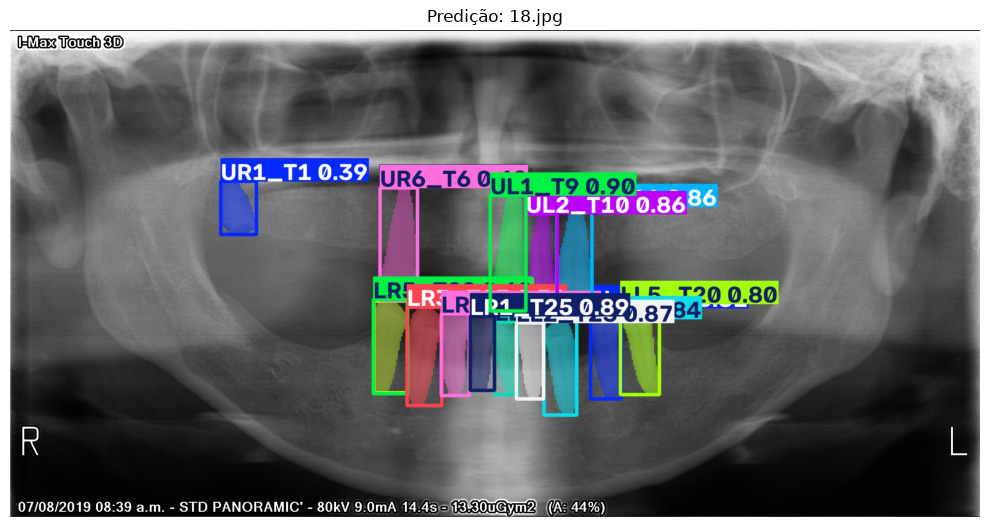

In [3]:
from ultralytics import YOLO

model = YOLO("runs/teeth_safe_run-3/weights/best.pt")
#results = model.predict(source="yolo_dataset/images/test/", save=True)

# Escolha a imagem aqui:
TEST_DIR = Path("yolo_dataset/images/test")
image_name = "18.jpg"   # <- altere para qualquer imagem da pasta test/


image_path = TEST_DIR / image_name

# Rodar predição e salvar resultado:
results = model.predict(source=str(image_path), save=True, conf=0.25)

# Exibir resultado inline no notebook:
save_dir = Path(results[0].save_dir)
result_img = Image.open(save_dir / image_name)

plt.figure(figsize=(10, 8))
plt.imshow(result_img)
plt.axis("off")
plt.title(f"Predição: {image_name}")
plt.tight_layout()
plt.show()

Melhorando a visualização da previsão com os nomes ao lado:


image 1/1 /home/eddygiusepe/3_DagsHub/Tooth_segmentation_with_YOLO/yolo_dataset/images/test/18.jpg: 352x640 1 UR1_T1, 1 UR6_T6, 1 UL1_T9, 1 UL2_T10, 1 UL3_T11, 1 LL5_T20, 1 LL4_T21, 1 LL3_T22, 1 LL2_T23, 1 LL1_T24, 1 LR1_T25, 1 LR2_T26, 1 LR3_T27, 1 LR4_T28, 1 LR5_T29, 4.4ms
Speed: 0.7ms preprocess, 4.4ms inference, 0.8ms postprocess per image at shape (1, 3, 352, 640)


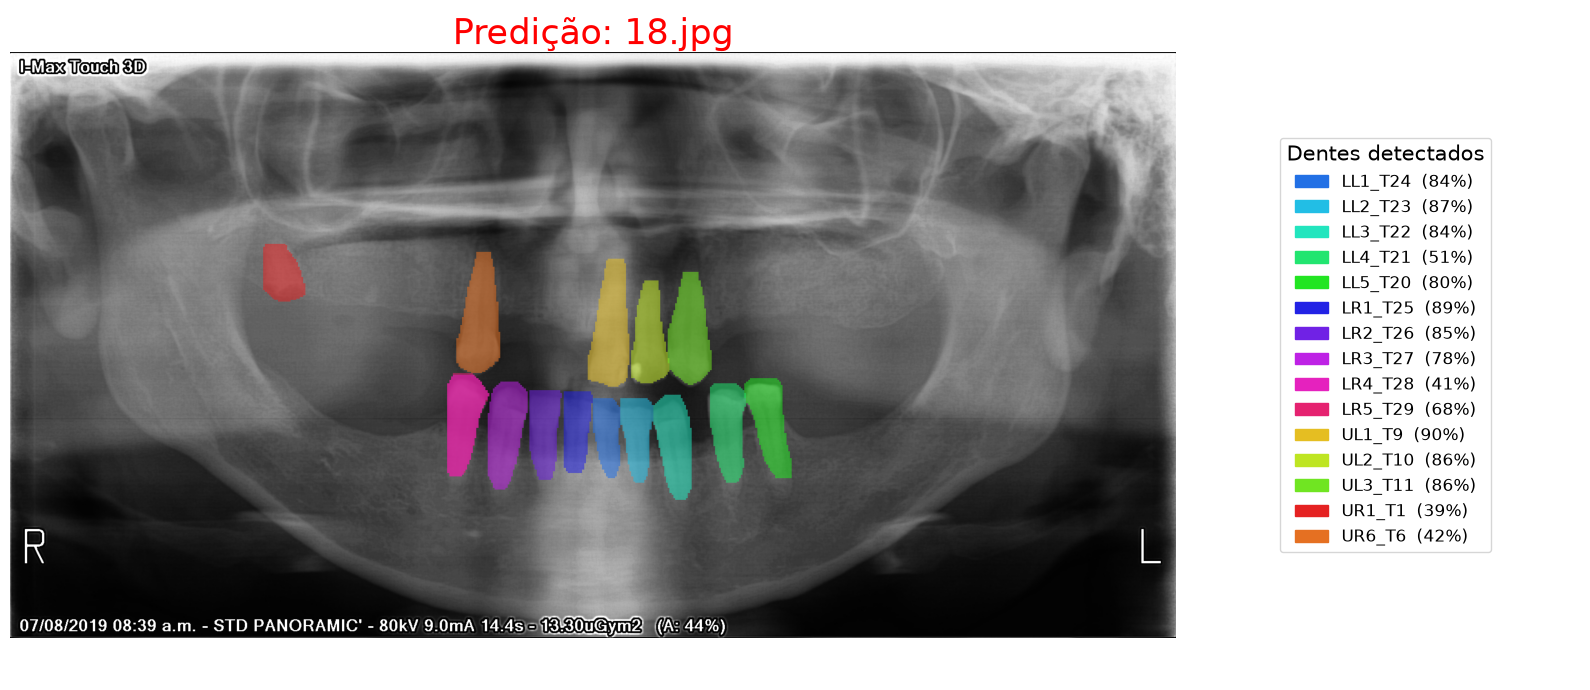

In [8]:
# Carregar o modelo treinado
model = YOLO("runs/teeth_safe_run-3/weights/best.pt")

# Escolha a imagem aqui
TEST_DIR = Path("yolo_dataset/images/test")
image_name = "18.jpg"   # <- altere para qualquer imagem da pasta test/


image_path = TEST_DIR / image_name

# Rodar predição:
results = model.predict(source=str(image_path), conf=0.35)

# Gerar cores ÚNICAS por cls_id detectado (HSV equidistante):
unique_cls_ids = sorted(set(int(b.cls) for b in results[0].boxes))
n = len(unique_cls_ids)

def make_unique_colors(cls_ids):
    """Uma cor RGB única por classe, espaçada uniformemente no HSV."""
    palette = {}
    for i, cls_id in enumerate(cls_ids):
        h = i / max(n, 1)
        r, g, b = colorsys.hsv_to_rgb(h, 0.85, 0.90)
        palette[cls_id] = (int(r * 255), int(g * 255), int(b * 255))
    return palette

cls_colors = make_unique_colors(unique_cls_ids)


# Carregar imagem original e sobrepor máscaras com cores únicas:
img = np.array(Image.open(image_path).convert("RGB"))
overlay = img.copy()
h_img, w_img = img.shape[:2]

if results[0].masks is not None:
    for mask_tensor, box in zip(results[0].masks.data, results[0].boxes):
        cls_id = int(box.cls)
        color  = cls_colors[cls_id]
        # Redimensionar máscara para o tamanho real da imagem:
        mask_resized = np.array(
            Image.fromarray((mask_tensor.cpu().numpy() * 255).astype(np.uint8))
                 .resize((w_img, h_img), Image.NEAREST)
        ) > 127
        # Aplicar cor com transparência (45% original + 55% cor da máscara)
        for c, val in enumerate(color):
            overlay[:, :, c] = np.where(
                mask_resized,
                overlay[:, :, c] * 0.45 + val * 0.55,
                overlay[:, :, c]
            ).astype(np.uint8)

# Coletar detecções únicas para a legenda (uma entrada por classe)
seen = set()
detections = []
for box in results[0].boxes:
    cls_id = int(box.cls)
    conf   = float(box.conf)
    nome   = model.names[cls_id]
    if cls_id not in seen:
        seen.add(cls_id)
        detections.append((nome, conf, cls_id))

detections.sort(key=lambda x: x[0])

# Legenda com cores únicas (normalizadas 0-1 para matplotlib)
legend_patches = [
    mpatches.Patch(
        color=tuple(c / 255 for c in cls_colors[cls_id]),
        label=f"{nome}  ({conf:.0%})"
    )
    for nome, conf, cls_id in detections
]

# Exibir imagem + legenda lateral
fig, (ax_img, ax_leg) = plt.subplots(
    1, 2, figsize=(16, 7),
    gridspec_kw={"width_ratios": [3, 1]}
)

ax_img.imshow(overlay)
ax_img.axis("off")
ax_img.set_title(f"Predição: {image_name}", fontsize=25, color="red")

ax_leg.axis("off")
ax_leg.legend(
    handles=legend_patches,
    loc="center",
    fontsize=12,
    title="Dentes detectados",
    title_fontsize=15,
    frameon=True,
)

plt.tight_layout()
plt.show()
